In [6]:
# ==========================================
# STEP 1: CONNECT GOOGLE DRIVE
# ==========================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected successfully!


In [7]:
# ==========================================
# STEP 2: IMPORT LIBRARIES
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [8]:
# ==========================================
# STEP 3: DATASET PATH
# ==========================================

DATASET_PATH = "/content/drive/MyDrive/Plant_Disease_Detection/dataset/PlantVillage/PlantVillage"

IMG_SIZE = 128
BATCH_SIZE = 32
SEED = 42

print("Dataset path:")
print(DATASET_PATH)

# Check if the dataset exists
if os.path.exists(DATASET_PATH):
    print("✅ Dataset found!")
else:
    print("❌ Dataset not found. Check the path.")

Dataset path:
/content/drive/MyDrive/Plant_Disease_Detection/dataset/PlantVillage/PlantVillage
✅ Dataset found!


In [9]:
# ==========================================
# STEP 4: LOAD DATASET
# ==========================================

train_data = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Get disease names
class_names = train_data.class_names

print("\nNumber of classes:", len(class_names))

print("\nDisease classes:")

for i, name in enumerate(class_names):
    print(i, ":", name)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.

Number of classes: 15

Disease classes:
0 : Pepper__bell___Bacterial_spot
1 : Pepper__bell___healthy
2 : Potato___Early_blight
3 : Potato___Late_blight
4 : Potato___healthy
5 : Tomato_Bacterial_spot
6 : Tomato_Early_blight
7 : Tomato_Late_blight
8 : Tomato_Leaf_Mold
9 : Tomato_Septoria_leaf_spot
10 : Tomato_Spider_mites_Two_spotted_spider_mite
11 : Tomato__Target_Spot
12 : Tomato__Tomato_YellowLeaf__Curl_Virus
13 : Tomato__Tomato_mosaic_virus
14 : Tomato_healthy


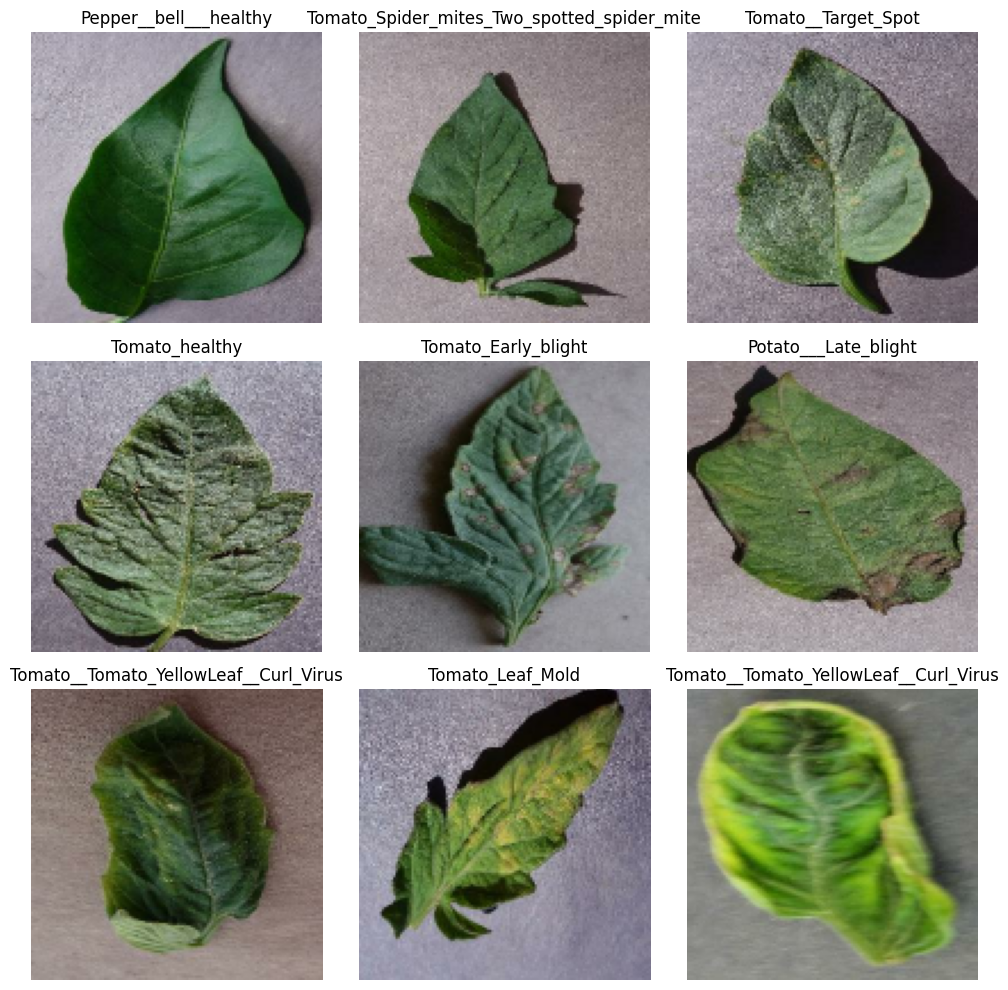

In [10]:
# ==========================================
# STEP 5: DISPLAY SAMPLE IMAGES
# ==========================================

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# STEP 6: CREATE CNN MODEL
# ==========================================

model = models.Sequential([

    # Input image
    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Normalize pixel values
    layers.Rescaling(1./255),

    # First CNN layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Second CNN layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Third CNN layer
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Convert feature maps into one vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Output layer - 15 diseases
    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ==========================================
# STEP 7: TRAIN MODEL
# ==========================================

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.7838 - loss: 0.6406 - val_accuracy: 0.8670 - val_loss: 0.3871
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.8003 - loss: 0.5746 - val_accuracy: 0.8701 - val_loss: 0.3705
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.8249 - loss: 0.5014 - val_accuracy: 0.8885 - val_loss: 0.3311
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.8347 - loss: 0.4760 - val_accuracy: 0.8864 - val_loss: 0.3358
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.8431 - loss: 0.4402 - val_accuracy: 0.8546 - val_loss: 0.4440


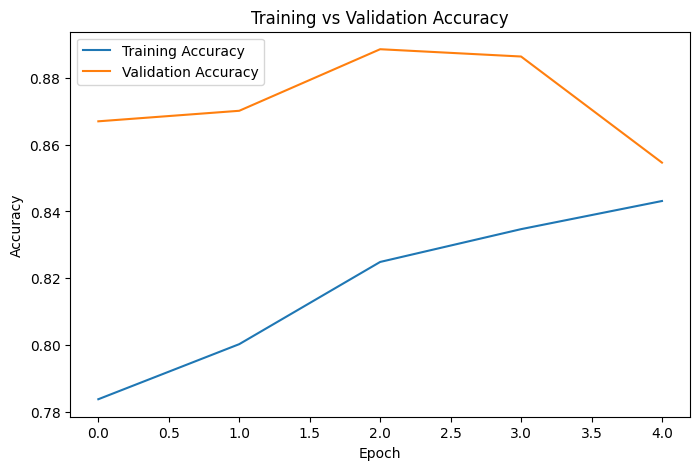

In [14]:
# ==========================================
# STEP 8: ACCURACY GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

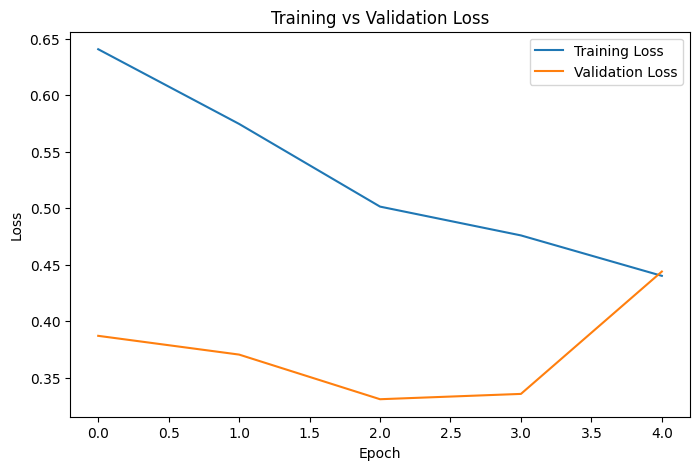

In [15]:
# ==========================================
# STEP 9: LOSS GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [16]:
# ==========================================
# STEP 10: MODEL EVALUATION
# ==========================================

loss, accuracy = model.evaluate(validation_data)

print("\n==============================")
print("MODEL RESULTS")
print("==============================")

print("Validation Loss:", round(loss, 4))

print(
    "Validation Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.8546 - loss: 0.4440

MODEL RESULTS
Validation Loss: 0.444
Validation Accuracy: 85.46 %


In [17]:
# ==========================================
# STEP 11: SAVE MODEL
# ==========================================

MODEL_PATH = "/content/drive/MyDrive/Plant_Disease_Detection/plant_disease_model.keras"

model.save(MODEL_PATH)

print("✅ Model saved successfully!")
print(MODEL_PATH)

✅ Model saved successfully!
/content/drive/MyDrive/Plant_Disease_Detection/plant_disease_model.keras


In [20]:
# ==========================================
# STEP 12: UPLOAD TEST IMAGE
# ==========================================

from google.colab import files

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

print("Image uploaded:", image_name)

Saving plant_img.png to plant_img.png
Image uploaded: plant_img.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step


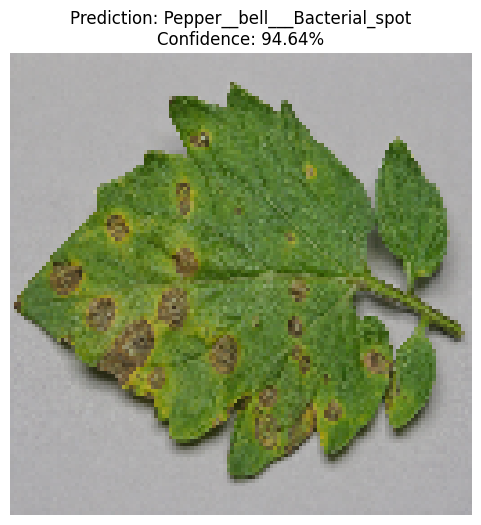


PREDICTION RESULT
Disease: Pepper__bell___Bacterial_spot
Confidence: 94.64%


In [21]:
# ==========================================
# STEP 13: PREDICT DISEASE
# ==========================================

from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

# Load image
image = load_img(
    image_name,
    target_size=(IMG_SIZE, IMG_SIZE)
)

# Convert image to array
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(
    image_array,
    axis=0
)

# Make prediction
prediction = model.predict(image_array)

# Find highest probability
predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

# Display result
plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

print("\n==============================")
print("PREDICTION RESULT")
print("==============================")

print("Disease:", predicted_class)

print(
    "Confidence:",
    f"{confidence:.2f}%"
)